In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

<h1>CUP - SVM</h1>
<p>Exploring the cup dataset with SVM Classifier.</p>
<hr/>

In [2]:
import importlib
import warnings
import numpy as np
from scipy.linalg import LinAlgWarning
from sklearn.exceptions import FitFailedWarning
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import cup_common as cc
import svm_common as sc
import cross_common as cr

In [3]:
# Ignore warning that might occur during grid search
warnings.filterwarnings("ignore", category=UserWarning, append=True)
warnings.filterwarnings("ignore", category=LinAlgWarning,append=True)
warnings.filterwarnings("ignore", category=FitFailedWarning, append=True)

In [4]:
importlib.reload(sc)
importlib.reload(cc)
importlib.reload(cr)

<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

<h2>Preparation</h2>

<h3>Hyperparameters</h3>

In [5]:

param_grid_default = [
    # LINEAR: no gamma, no degree
    {
        "model__estimator__kernel": ["linear"],
        "model__estimator__alpha": np.logspace(-4, 2, 7),
    },

    # RBF: alpha + gamma
    {
        "model__estimator__kernel": ["rbf"],
        "model__estimator__alpha": np.logspace(-4, 2, 7),
        "model__estimator__gamma": np.logspace(-4, 1, 6),
    },

    # POLY: alpha + gamma + degree
    {
        "model__estimator__kernel": ["poly"],
        "model__estimator__alpha": np.logspace(-4, 2, 7),
        "model__estimator__gamma": np.logspace(-4, 0, 5),
        "model__estimator__degree": [2, 3],
    },

    # SIGMOID: alpha + gamma (range più stretto)
    {
        "model__estimator__kernel": ["sigmoid"],
        "model__estimator__alpha": np.logspace(-4, 2, 7),
        "model__estimator__gamma": np.logspace(-6, -1, 6),
    },
]

# We only test SVR
pipe_default = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", MultiOutputRegressor(KernelRidge())),
])

# Common scoring
default_metric = "mee"
scoring = cr.common_scoring(default_metric)

# Common CV fold strategy
outer_cv = cr.common_fold_strategy()


<h3>Data Loading</h3>

In [6]:
df_train, df_test = cc.load_set()
X_tr, y_tr = cc.prepare_dataset(df_train)
X_ts, y_ts = cc.prepare_dataset(df_test)
features_names = X_tr.columns
cr.dataset_introspection(X_tr, X_ts)

,Property,Training,Test
0,Number of samples,500,1000
1,Number of features,10,10
2,Class values,[],[]
3,Class balance,[],[]


<h3>Baseline</h3>

In [7]:
importlib.reload(cr)
model_baseline = cr.model_baseline(X_tr, y_tr, outer_cv)

----------------------------------------
Baseline: DummyRegressor()
Mean baseline: 35.79302825927734
Scorer: make_scorer(neg_mean_euclidean_error, greater_is_better=False, response_method='predict')
Raw scores: [-36.10307312 -34.5480423  -35.62013626 -35.9157486  -36.77814102]


<h3>Best Model</h3>

In [8]:
# Perform a grid search
gs = GridSearchCV(
    estimator = pipe_default,
    param_grid = param_grid_default,
    cv = outer_cv,
    scoring = scoring,
    n_jobs = -1 # use all available cores
)

# Fit TR features and labels into grid
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gs.fit(X_tr, y_tr)

In [9]:
best_estimator = gs.best_estimator_
best_model, best_params = cr.extract_best_pipeline_metrics_from_grid(gs)
cr.grid_introspection(gs)

Grid summary
----------------------------------------
Total model explored: 161  splits: 5
Best params: {'model__estimator__alpha': np.float64(0.1), 'model__estimator__gamma': np.float64(1.0), 'model__estimator__kernel': 'rbf'}
Best score: -17.44827308654785
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 MultiOutputRegressor(estimator=KernelRidge(alpha=np.float64(0.1),
                                                            gamma=np.float64(1.0),
                                                            kernel='rbf')))])


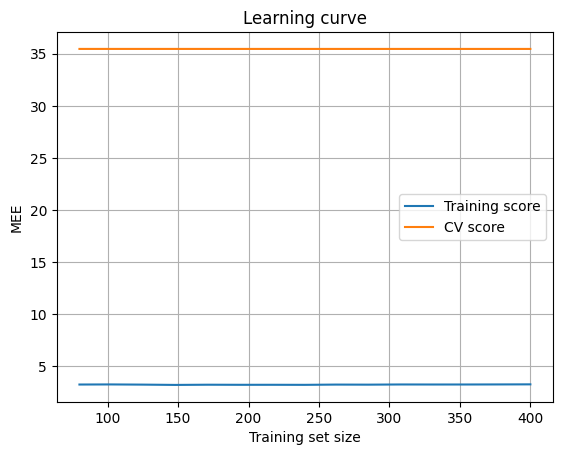

In [10]:
importlib.reload(cr)
cr.plot_learning_curve(best_model, X_tr, y_tr, outer_cv, scoring=scoring)

<h2>Model estimation</h2>
<p>The model is estimated trough two different approaches: non nested and nested KFold.</p>
<hr/>

<h3>Non nested Cross Validation</h3>

In [11]:
from sklearn import clone

runner = cr.SklearnRegressorRunner(clone(gs.best_estimator_).set_params(**gs.best_params_))
kf_result = cr.kfold(runner, X_tr, y_tr, outer_cv)

  
Perform fold: 1, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 101.6272
Validation RMSE | 10.0810
Validation MEE  | 16.9364
Validation MAE  | 7.5098
Train           | samples: 400
Validation      | samples: 100
  
Perform fold: 2, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 96.7836
Validation RMSE | 9.8379
Validation MEE  | 17.2343
Validation MAE  | 7.6586
Train           | samples: 400
Validation      | samples: 100
  
Perform fold: 3, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 94.7815
Validation RMSE | 9.7356
Validation MEE  | 17.2264
Validation MAE  | 7.6323
Train           | samples: 400
Validation      | samples: 100
  
Perform fold: 4, train size: 400, val size: 100
 
Fold summary

In [12]:
best_idx = gs.best_index_
mean_score = gs.cv_results_["mean_test_score"][best_idx]
std_score  = gs.cv_results_["std_test_score"][best_idx]
print(f"Best CV grid score: {mean_score:.4f} ± {std_score:.4f}")
mean, std = cr.extract_mean_std(kf_result, f"fold_vl_{default_metric}")
print(f"Best CV func score: {mean:.4f} ± {std:.4f}")

Best CV grid score: -17.4483 ± 0.9174
Best CV func score: 17.4483 ± 0.9174


<h3>Nested Cross Validation</h3>

In [13]:
importlib.reload(cr)

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

inner_cv = cr.common_fold_strategy(n_split=3)
outer_cv = outer_cv

gs_inner = GridSearchCV(
    pipe_default,
    param_grid=param_grid_default,
    scoring=scoring,
    cv=inner_cv,
    n_jobs=-1,
    return_train_score=True
)
nested_runner = cr.SklearnNestedRegressorRunner(gs_inner)
with warnings.catch_warnings():
    nested_result = cr.kfold(nested_runner, X_tr, y_tr, outer_cv)

  
Perform fold: 1, train size: 400, val size: 100
Grid summary
----------------------------------------
Total model explored: 161  splits: 3
Best params: {'model__estimator__alpha': np.float64(0.1), 'model__estimator__gamma': np.float64(1.0), 'model__estimator__kernel': 'rbf'}
Best score: -18.143024444580078
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 MultiOutputRegressor(estimator=KernelRidge(alpha=np.float64(0.1),
                                                            gamma=np.float64(1.0),
                                                            kernel='rbf')))])
 
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 101.6272
Validation RMSE | 10.0810
Validation MEE  | 16.9364
Validation MAE  | 7.5098
Train           | samples: 400
Validation      | samples: 100
  
Perform fold: 2, train size: 400, val size: 100
Grid summary
-----------------------------------

<p>This plot shows the evolution of training and cross-validation errors as the training set size increases. The learning curve helps assess whether the model suffers from underfitting or overfitting and whether performance is limited by model capacity or by intrinsic noise in the data.</p>

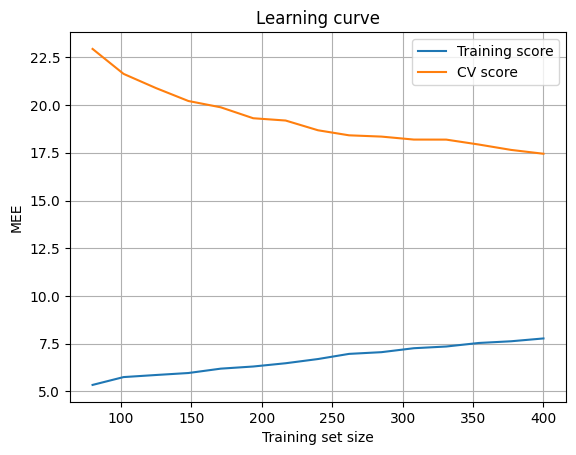

In [14]:
importlib.reload(cr)
cr.plot_learning_curve(best_estimator, X_tr, y_tr, outer_cv, scoring=gs.scoring)

<h3>Results</h3>
<hr/>

<p>We expect that non nested KFold result has more optimistic metrics in respect to nested KFold.</p>

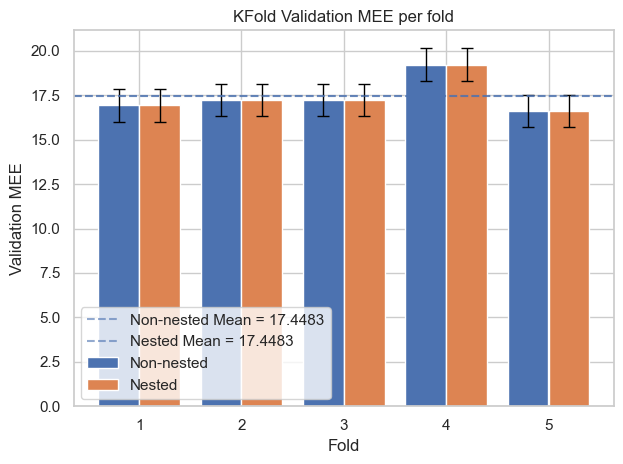

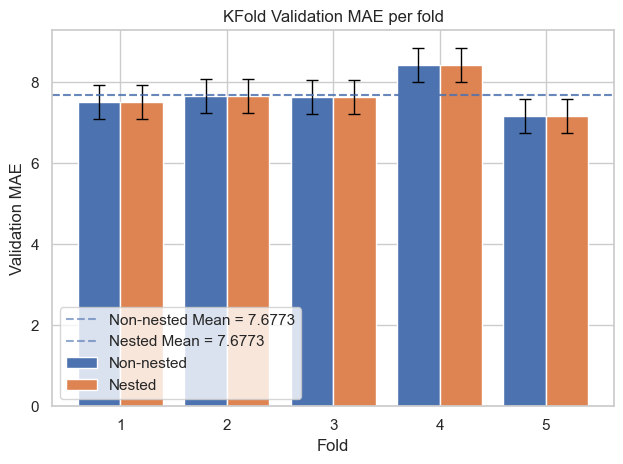

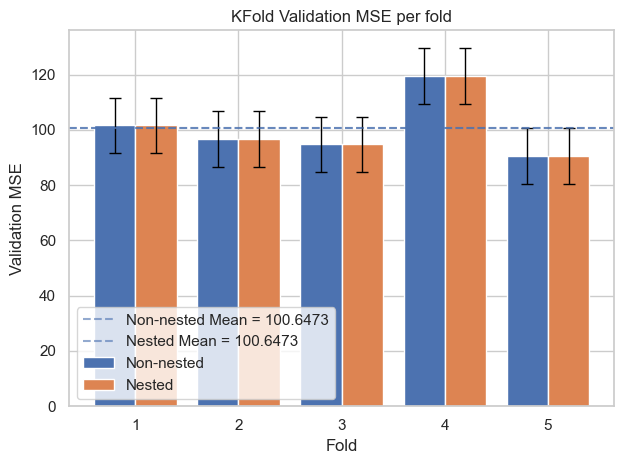

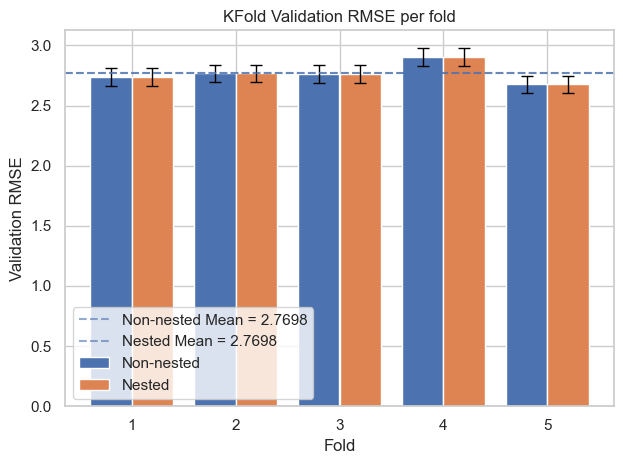

In [15]:
for metric in ["mee","mae","mse","rmse"]:
    cr.plot_kfold_metric([(kf_result,"Non-nested"), (nested_result, "Nested")], metric)

In [16]:
for metric in ["mee","mae","mse","rmse"]:
    display(cr.kfold_regression_table(kf_result, use=metric))

,TR_MEE,VL_MEE,Gap(TR-VL)
Fold,,,
1,7.806810,16.936386,9.129576
2,8.016496,17.234268,9.217772
3,7.813941,17.226448,9.412507
4,7.475341,19.226307,11.750966
5,7.762016,16.617956,8.855940
MEAN,7.774921,17.448273,9.673352
STD,0.194173,1.025654,1.178551


,TR_MAE,VL_MAE,Gap(TR-VL)
Fold,,,
1,3.456592,7.509850,4.053258
2,3.551797,7.658602,4.106805
3,3.422894,7.632256,4.209362
4,3.272137,8.424527,5.152390
5,3.440280,7.161308,3.721027
MEAN,3.428740,7.677308,4.248568
STD,0.100760,0.462335,0.537348


,TR_MSE,VL_MSE,Gap(TR-VL)
Fold,,,
1,21.727554,101.627235,79.899681
2,23.304224,96.783646,73.479422
3,22.134285,94.781525,72.647240
4,20.852411,119.493706,98.641294
5,21.405598,90.550476,69.144878
MEAN,21.884814,100.647318,78.762503
STD,0.921574,11.263084,11.771423


,TR_RMSE,VL_RMSE,Gap(TR-VL)
Fold,,,
1,1.859191,2.740410,0.881219
2,1.884621,2.767418,0.882797
3,1.850106,2.762654,0.912547
4,1.808905,2.902504,1.093599
5,1.854799,2.676062,0.821263
MEAN,1.851525,2.769810,0.918285
STD,0.027310,0.082640,0.103458


In [17]:
importlib.reload(cr)
bootstrap_samples = 50
bootstrap_rstate = 42
samples = cr.generate_bootstrap_samples_from_dataset(X_tr, y_tr, n_samples=bootstrap_samples, random_state=bootstrap_rstate)
bootstrap_params = {"silence_output": True}

with warnings.catch_warnings():
    bootstrap_scores = cr.bootstrap_out_of_bag_scores(nested_runner, X_tr, y_tr, samples, bootstrap_params=bootstrap_params)


In [18]:
cr.aggregate_scores(bootstrap_scores)

,metric,mean,std,percentage
0,mee,21.29,0.81,3.81
1,mse,151.77,11.33,7.47
2,rmse,12.31,0.46,3.76
3,mae,9.26,0.38,4.11
4,r2,0.49,0.03,6.87


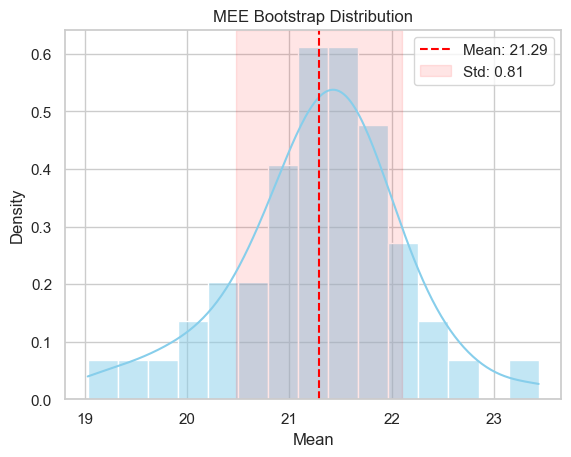

In [20]:
cr.plot_bootstrap_distribution([metric.mee for metric in bootstrap_scores])

<h2>Test predictions</h2>
<hr/>

In [21]:
unfitted_model = runner.new_model()
fitted_model = runner.fit(unfitted_model, X_tr, y_tr)
y_pred = runner.predict(fitted_model, X_ts)

In [22]:
print(y_pred)

[[-1.6775169e+00 -2.0437698e+00  2.0170441e+00 -1.2453800e+01]
 [ 2.8324585e+00 -1.0611084e+01 -3.8077408e+01  1.4743248e+01]
 [-4.0720739e+00 -2.2500563e+00  2.5310755e-02  5.4710321e+00]
 ...
 [-1.0130135e+01  1.3044361e+01  2.2212772e+01 -7.3889847e+00]
 [ 1.6627747e+01  1.4378212e+01 -3.2589737e+01  1.0686317e+01]
 [ 6.8806839e-01 -1.0389748e+00  3.1597481e+00 -7.2684250e+00]]


<hr/>